# Longstaff-Schwartz Method for American Option Pricing

This notebook demonstrates the Longstaff-Schwartz algorithm for pricing American options on zero bonds using Monte Carlo simulation and regression.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import sys
sys.path.append('../src')

from ls_pricing.core.curves import YieldCurve
from ls_pricing.core.hull_white import HullWhiteModel
from ls_pricing.engine.monte_carlo import MonteCarloEngine
from ls_pricing.engine.longstaff_schwartz import LongstaffSchwartzEngine, RegressionBasis

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette("husl")

## 1. Setup Market Data and Models

In [2]:
# Create yield curve
tenors = np.array([0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0])
rates = np.array([0.0425, 0.0415, 0.0395, 0.0380, 0.0379, 0.0393, 0.0412, 0.0432, 0.0483, 0.0479])
curve_date = datetime(2024, 1, 1)

yield_curve = YieldCurve(tenors, rates, curve_date)

# Create Hull-White model
a = 0.05  # Mean reversion
sigma = 0.01  # Volatility
hw_model = HullWhiteModel(a=a, sigma=sigma, yield_curve=yield_curve)

# Create Monte Carlo engine
mc_engine = MonteCarloEngine(
    model=hw_model,
    n_paths=10000,
    n_steps=50
)

# Create Longstaff-Schwartz engine
ls_engine = LongstaffSchwartzEngine(
    mc_engine=mc_engine,
    basis_type='laguerre',
    basis_degree=3
)

print(f"Model Setup Complete:")
print(f"  Hull-White parameters: a={a}, sigma={sigma}")
print(f"  Monte Carlo paths: {mc_engine.n_paths}")
print(f"  Time steps: {mc_engine.n_steps}")
print(f"  Basis functions: Laguerre polynomials (degree 3)")

Model Setup Complete:
  Hull-White parameters: a=0.05, sigma=0.01
  Monte Carlo paths: 10000
  Time steps: 50
  Basis functions: Laguerre polynomials (degree 3)


## 2. Visualize Laguerre Basis Functions

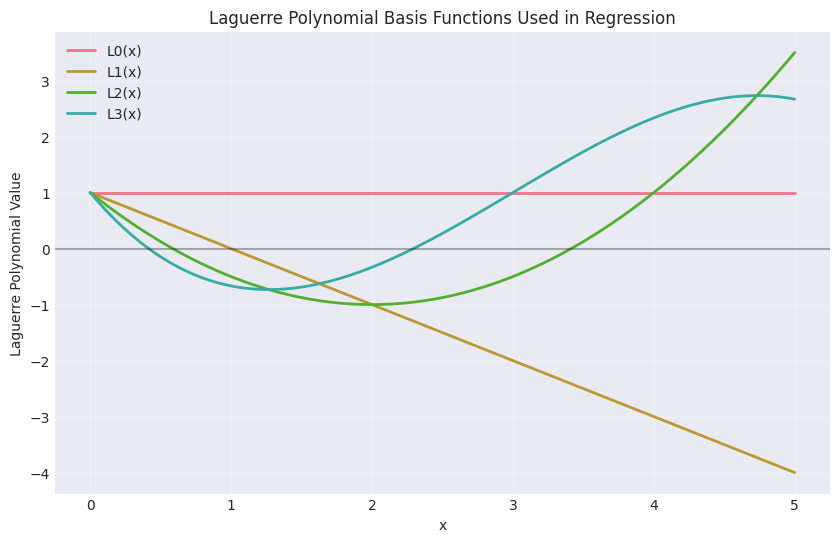

Laguerre Polynomials:
L₀(x) = 1
L₁(x) = 1 - x
L₂(x) = 1 - 2x + x²/2
L₃(x) = 1 - 3x + 3x²/2 - x³/6


In [3]:
# Visualize the Laguerre polynomial basis functions
x = np.linspace(0, 5, 1000)
basis = RegressionBasis.laguerre_polynomials(x, degree=3)

plt.figure(figsize=(10, 6))
for i in range(4):
    plt.plot(x, basis[:, i], linewidth=2, label=f'L{i}(x)')

plt.xlabel('x')
plt.ylabel('Laguerre Polynomial Value')
plt.title('Laguerre Polynomial Basis Functions Used in Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.show()

# Show the mathematical forms
print("Laguerre Polynomials:")
print("L₀(x) = 1")
print("L₁(x) = 1 - x")
print("L₂(x) = 1 - 2x + x²/2")
print("L₃(x) = 1 - 3x + 3x²/2 - x³/6")

## 3. Price American vs European Options

In [4]:
# Option parameters
strike = 0.82
option_maturity = 2.0
bond_maturity = 5.0

# Price American option
american_result = ls_engine.price_american_option(
    strike=strike,
    option_maturity=option_maturity,
    bond_maturity=bond_maturity,
    option_type='call'
)

# Price European option
european_result = ls_engine.price_european_option(
    strike=strike,
    option_maturity=option_maturity,
    bond_maturity=bond_maturity,
    option_type='call'
)

# Display results
print("Pricing Results:")
print("="*50)
print(f"Option Type: call on {bond_maturity:.0f}-year zero bond")
print(f"Strike: {strike:.3f}")
print(f"Option Maturity: {option_maturity} years")
print("\nAmerican Option:")
print(f"  Price: ${american_result['price']:.4f}")
print(f"  Std Error: ${american_result['std_error']:.4f}")
print(f"  Exercise Probability: {american_result['exercise_prob']:.1%}")
print(f"  Mean Exercise Time: {american_result['mean_exercise_time']:.2f} years")
print("\nEuropean Option:")
print(f"  Price: ${european_result['price']:.4f}")
print(f"  Std Error: ${european_result['std_error']:.4f}")
print("\nEarly Exercise Premium:")
premium = american_result['price'] - european_result['price']
print(f"  Absolute: ${premium:.4f}")
print(f"  Relative: {premium/european_result['price']*100:.1f}%")

Pricing Results:
Option Type: call on 5-year zero bond
Strike: 0.820
Option Maturity: 2.0 years

American Option:
  Price: $0.0634
  Std Error: $0.0003
  Exercise Probability: 98.2%
  Mean Exercise Time: 1.99 years

European Option:
  Price: $0.0642
  Std Error: $0.0003

Early Exercise Premium:
  Absolute: $-0.0007
  Relative: -1.2%


## 4. Analyze Exercise Boundary

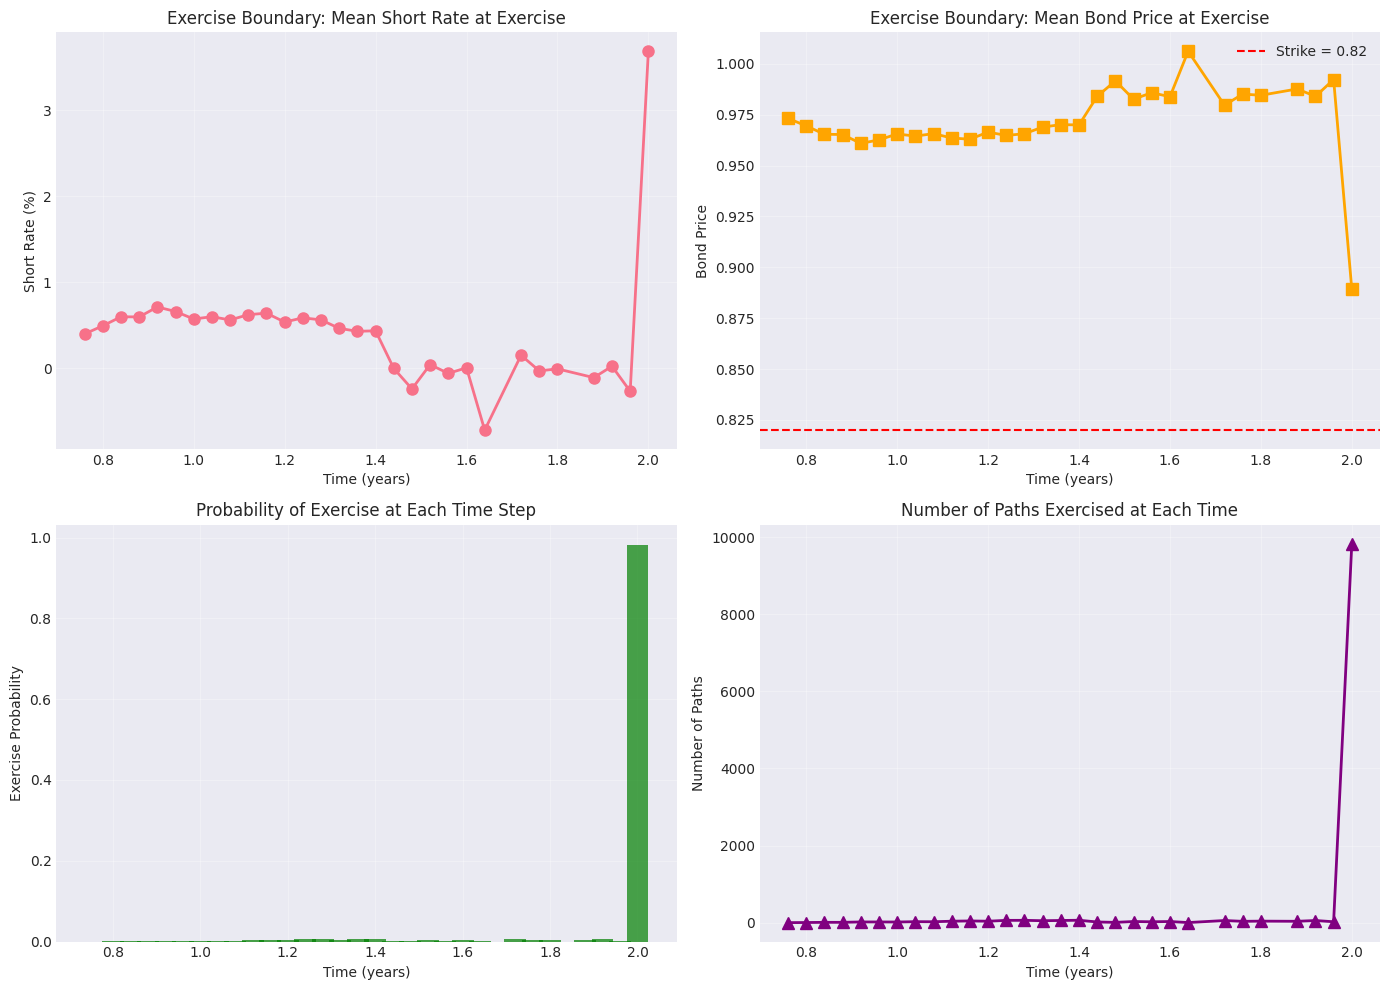

In [5]:
# Extract exercise boundary information
exercise_boundary = american_result['exercise_boundary']

if len(exercise_boundary) > 0:
    times = sorted(exercise_boundary.keys())
    mean_rates = [exercise_boundary[t]['mean_rate'] for t in times]
    mean_bond_prices = [exercise_boundary[t]['mean_bond_price'] for t in times]
    exercise_probs = [exercise_boundary[t]['exercise_prob'] for t in times]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Exercise boundary in terms of short rate
    axes[0, 0].plot(times, np.array(mean_rates)*100, 'o-', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Time (years)')
    axes[0, 0].set_ylabel('Short Rate (%)')
    axes[0, 0].set_title('Exercise Boundary: Mean Short Rate at Exercise')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Exercise boundary in terms of bond price
    axes[0, 1].plot(times, mean_bond_prices, 's-', linewidth=2, markersize=8, color='orange')
    axes[0, 1].axhline(y=strike, color='red', linestyle='--', label=f'Strike = {strike}')
    axes[0, 1].set_xlabel('Time (years)')
    axes[0, 1].set_ylabel('Bond Price')
    axes[0, 1].set_title('Exercise Boundary: Mean Bond Price at Exercise')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Exercise probability over time
    axes[1, 0].bar(times, exercise_probs, width=0.05, alpha=0.7, color='green')
    axes[1, 0].set_xlabel('Time (years)')
    axes[1, 0].set_ylabel('Exercise Probability')
    axes[1, 0].set_title('Probability of Exercise at Each Time Step')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Number of paths exercised
    n_exercised = [exercise_boundary[t]['n_exercised'] for t in times]
    axes[1, 1].plot(times, n_exercised, '^-', linewidth=2, markersize=8, color='purple')
    axes[1, 1].set_xlabel('Time (years)')
    axes[1, 1].set_ylabel('Number of Paths')
    axes[1, 1].set_title('Number of Paths Exercised at Each Time')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No early exercise occurred in this simulation.")

## 5. Compare Different Strike Prices

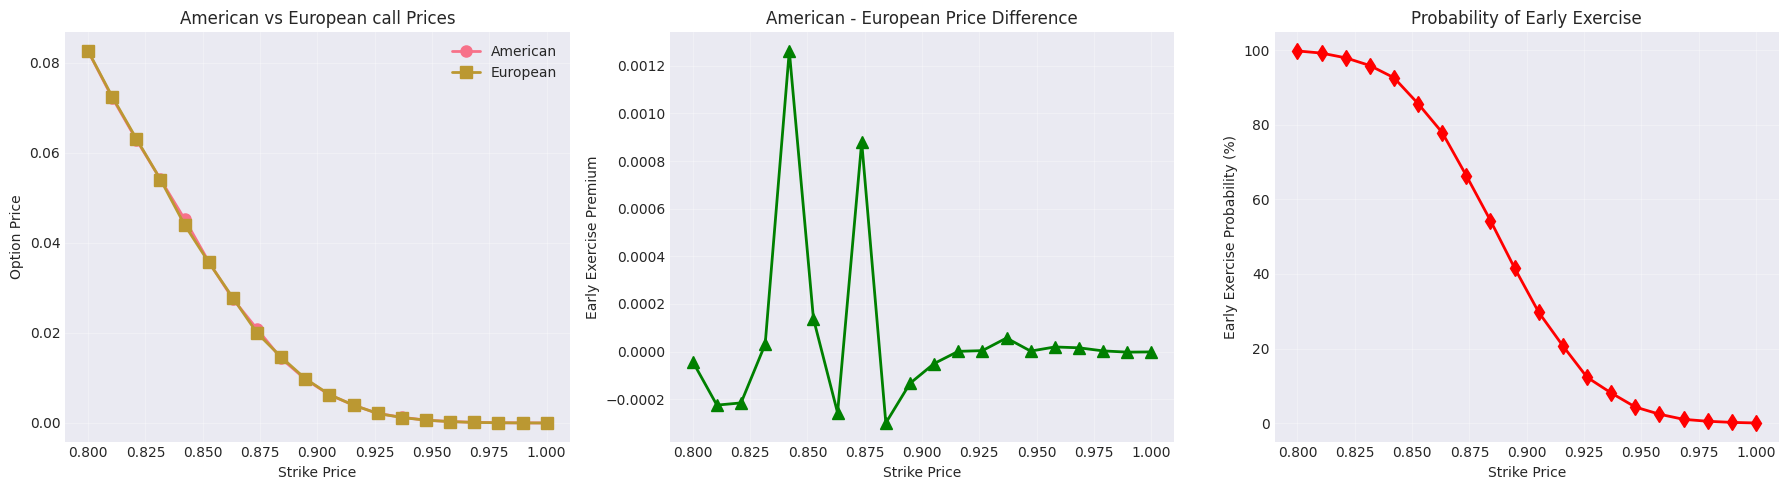

In [6]:
# Compare American and European options across different strikes
strikes = np.linspace(0.80, 1.00, 20)
american_prices = []
european_prices = []
early_exercise_probs = []

for K in strikes:
    # American
    am_result = ls_engine.price_american_option(
        strike=K,
        option_maturity=option_maturity,
        bond_maturity=bond_maturity,
        option_type='call'
    )
    american_prices.append(am_result['price'])
    early_exercise_probs.append(am_result['exercise_prob'])
    
    # European
    eu_result = ls_engine.price_european_option(
        strike=K,
        option_maturity=option_maturity,
        bond_maturity=bond_maturity,
        option_type='call'
    )
    european_prices.append(eu_result['price'])

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Option prices
ax1.plot(strikes, american_prices, 'o-', label='American', linewidth=2, markersize=8)
ax1.plot(strikes, european_prices, 's-', label='European', linewidth=2, markersize=8)
ax1.set_xlabel('Strike Price')
ax1.set_ylabel('Option Price')
ax1.set_title('American vs European call Prices')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Early exercise premium
premium = np.array(american_prices) - np.array(european_prices)
ax2.plot(strikes, premium, '^-', color='green', linewidth=2, markersize=8)
ax2.set_xlabel('Strike Price')
ax2.set_ylabel('Early Exercise Premium')
ax2.set_title('American - European Price Difference')
ax2.grid(True, alpha=0.3)

# Plot 3: Exercise probability
ax3.plot(strikes, np.array(early_exercise_probs)*100, 'd-', color='red', linewidth=2, markersize=8)
ax3.set_xlabel('Strike Price')
ax3.set_ylabel('Early Exercise Probability (%)')
ax3.set_title('Probability of Early Exercise')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Visualize Regression at a Single Time Step

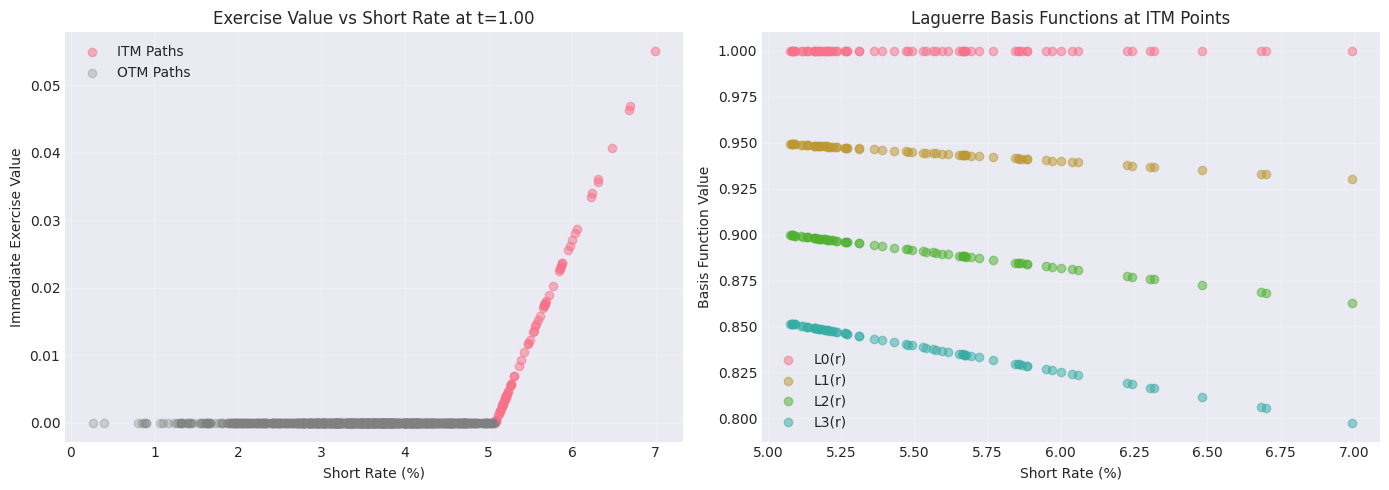

At time 1.00:
  Number of ITM paths: 75
  Number of OTM paths: 925
  Mean short rate (ITM): 5.54%


In [7]:
# Generate paths for visualization
paths = mc_engine.generate_paths(T=option_maturity, seed=42)
rates = paths['rates']
times = paths['times']

# Pick a time step in the middle
step = len(times) // 2
current_time = times[step]

# Use a subset of paths for visualization
n_paths_viz = min(1000, rates.shape[0])
rates_subset = rates[:n_paths_viz, :]

# Calculate bond prices at this time
bond_prices = np.array([
    hw_model.zero_bond_price(
        t=current_time,
        T=bond_maturity,
        r_t=rates_subset[i, step]
    ) for i in range(n_paths_viz)
])

# Calculate immediate exercise value
immediate_value = np.maximum(strike - bond_prices, 0)

# Identify ITM paths
itm_mask = immediate_value > 0
X_itm = rates_subset[itm_mask, step]

if len(X_itm) > 10:
    # Generate basis and plot
    plt.figure(figsize=(14, 5))
    
    # Plot 1: Scatter of payoff vs short rate
    plt.subplot(1, 2, 1)
    plt.scatter(rates_subset[itm_mask, step]*100, immediate_value[itm_mask], 
                alpha=0.5, label='ITM Paths')
    plt.scatter(rates_subset[~itm_mask, step]*100, immediate_value[~itm_mask], 
                alpha=0.3, color='gray', label='OTM Paths')
    plt.xlabel('Short Rate (%)')
    plt.ylabel('Immediate Exercise Value')
    plt.title(f'Exercise Value vs Short Rate at t={current_time:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Basis functions for ITM paths
    plt.subplot(1, 2, 2)
    basis = RegressionBasis.laguerre_polynomials(X_itm, degree=3)
    for i in range(4):
        plt.scatter(X_itm*100, basis[:, i], alpha=0.5, label=f'L{i}(r)')
    plt.xlabel('Short Rate (%)')
    plt.ylabel('Basis Function Value')
    plt.title('Laguerre Basis Functions at ITM Points')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"At time {current_time:.2f}:")
    print(f"  Number of ITM paths: {np.sum(itm_mask)}")
    print(f"  Number of OTM paths: {np.sum(~itm_mask)}")
    print(f"  Mean short rate (ITM): {np.mean(X_itm)*100:.2f}%")
else:
    print(f"Not enough ITM paths at time {current_time:.2f} for visualization")

## 7. Convergence Analysis

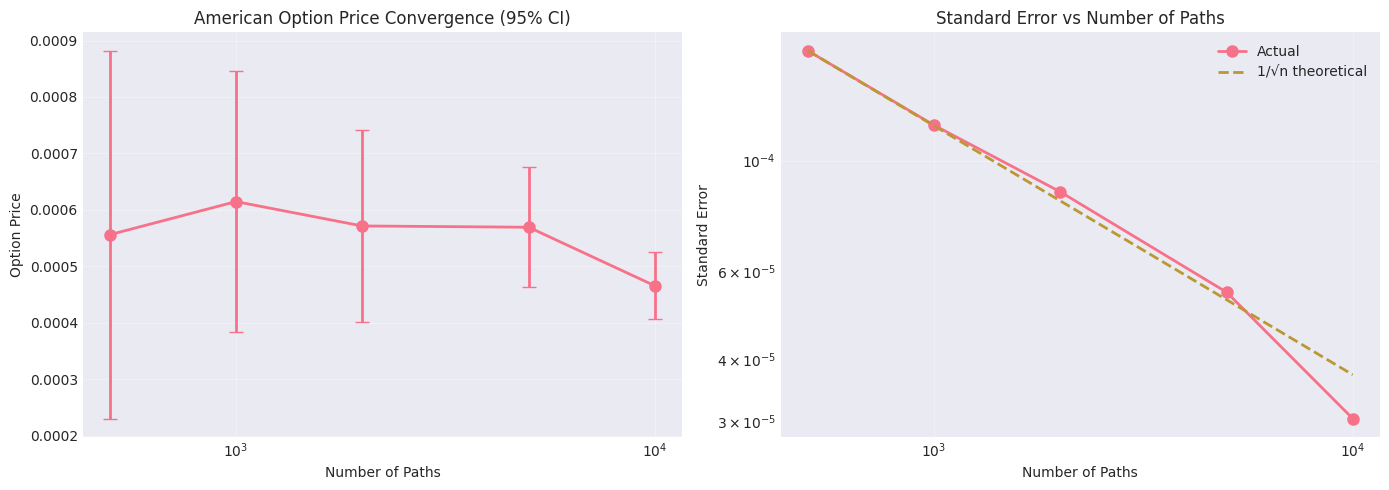

Convergence Results for Strike = 0.95:
   Paths    Price  Std Err Ex. Prob
------------------------------------
     500   0.0006   0.0002     4.2%
    1000   0.0006   0.0001     4.5%
    2000   0.0006   0.0001     4.0%
    5000   0.0006   0.0001     3.8%
   10000   0.0005   0.0000     3.6%


In [8]:
# Test convergence with different numbers of paths
path_counts = [500, 1000, 2000, 5000, 10000]
prices = []
std_errors = []
exercise_probs = []

strike_conv = 0.95

for n_paths in path_counts:
    # Create new MC engine with different path count
    mc_temp = MonteCarloEngine(hw_model, n_paths=n_paths, n_steps=50)
    ls_temp = LongstaffSchwartzEngine(mc_temp)
    
    # Price option
    result = ls_temp.price_american_option(
        strike=strike_conv,
        option_maturity=option_maturity,
        bond_maturity=bond_maturity,
        option_type='call'
    )
    
    prices.append(result['price'])
    std_errors.append(result['std_error'])
    exercise_probs.append(result['exercise_prob'])

# Plot convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Price convergence with confidence bands
ax1.errorbar(path_counts, prices, yerr=np.array(std_errors)*1.96, 
             fmt='o-', capsize=5, linewidth=2, markersize=8)
ax1.set_xlabel('Number of Paths')
ax1.set_ylabel('Option Price')
ax1.set_title('American Option Price Convergence (95% CI)')
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

# Plot 2: Standard error decay
ax2.loglog(path_counts, std_errors, 'o-', linewidth=2, markersize=8, label='Actual')
# Theoretical 1/sqrt(n) decay
theoretical = std_errors[0] * np.sqrt(path_counts[0]) / np.sqrt(path_counts)
ax2.loglog(path_counts, theoretical, '--', linewidth=2, label='1/√n theoretical')
ax2.set_xlabel('Number of Paths')
ax2.set_ylabel('Standard Error')
ax2.set_title('Standard Error vs Number of Paths')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Convergence Results for Strike = {strike_conv}:")
print(f"{'Paths':>8} {'Price':>8} {'Std Err':>8} {'Ex. Prob':>8}")
print("-" * 36)
for i, n in enumerate(path_counts):
    print(f"{n:8d} {prices[i]:8.4f} {std_errors[i]:8.4f} {exercise_probs[i]:8.1%}")

## 8. Compare Basis Functions

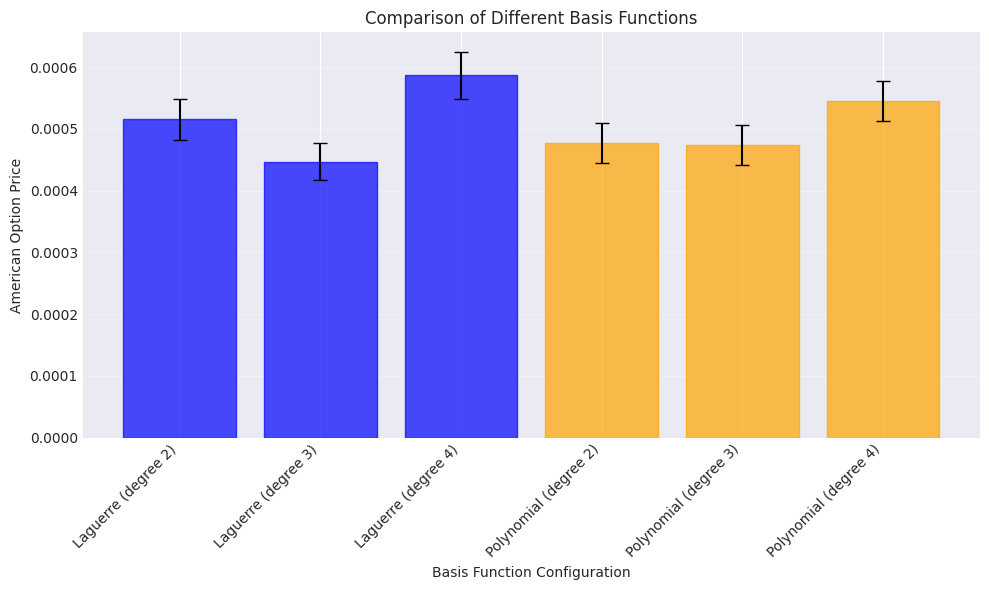

Basis Function Comparison:
Configuration           Price  Std Err Ex. Prob
------------------------------------------------
Laguerre (degree 2)    0.0005   0.0000     3.5%
Laguerre (degree 3)    0.0004   0.0000     3.6%
Laguerre (degree 4)    0.0006   0.0000     3.9%
Polynomial (degree 2)   0.0005   0.0000     3.5%
Polynomial (degree 3)   0.0005   0.0000     3.4%
Polynomial (degree 4)   0.0005   0.0000     3.8%


In [9]:
# Compare different basis functions and degrees
basis_configs = [
    ('laguerre', 2, 'Laguerre (degree 2)'),
    ('laguerre', 3, 'Laguerre (degree 3)'),
    ('laguerre', 4, 'Laguerre (degree 4)'),
    ('polynomial', 2, 'Polynomial (degree 2)'),
    ('polynomial', 3, 'Polynomial (degree 3)'),
    ('polynomial', 4, 'Polynomial (degree 4)')
]

results = []

for basis_type, degree, label in basis_configs:
    ls_temp = LongstaffSchwartzEngine(
        mc_engine=mc_engine,
        basis_type=basis_type,
        basis_degree=degree
    )
    
    result = ls_temp.price_american_option(
        strike=0.95,
        option_maturity=option_maturity,
        bond_maturity=bond_maturity,
        option_type='call'
    )
    
    results.append({
        'label': label,
        'price': result['price'],
        'std_error': result['std_error'],
        'exercise_prob': result['exercise_prob']
    })

# Create comparison plot
fig, ax = plt.subplots(figsize=(10, 6))

labels = [r['label'] for r in results]
prices = [r['price'] for r in results]
errors = [r['std_error'] for r in results]

x = np.arange(len(labels))
bars = ax.bar(x, prices, yerr=errors, capsize=5, alpha=0.7)

# Color bars by basis type
for i, bar in enumerate(bars):
    if 'Laguerre' in labels[i]:
        bar.set_color('blue')
    else:
        bar.set_color('orange')

ax.set_xlabel('Basis Function Configuration')
ax.set_ylabel('American Option Price')
ax.set_title('Comparison of Different Basis Functions')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed results
print("Basis Function Comparison:")
print(f"{'Configuration':20} {'Price':>8} {'Std Err':>8} {'Ex. Prob':>8}")
print("-" * 48)
for r in results:
    print(f"{r['label']:20} {r['price']:8.4f} {r['std_error']:8.4f} {r['exercise_prob']:8.1%}")

## 9. 3D Visualization of Option Value Surface

Calculating option prices for surface plot...


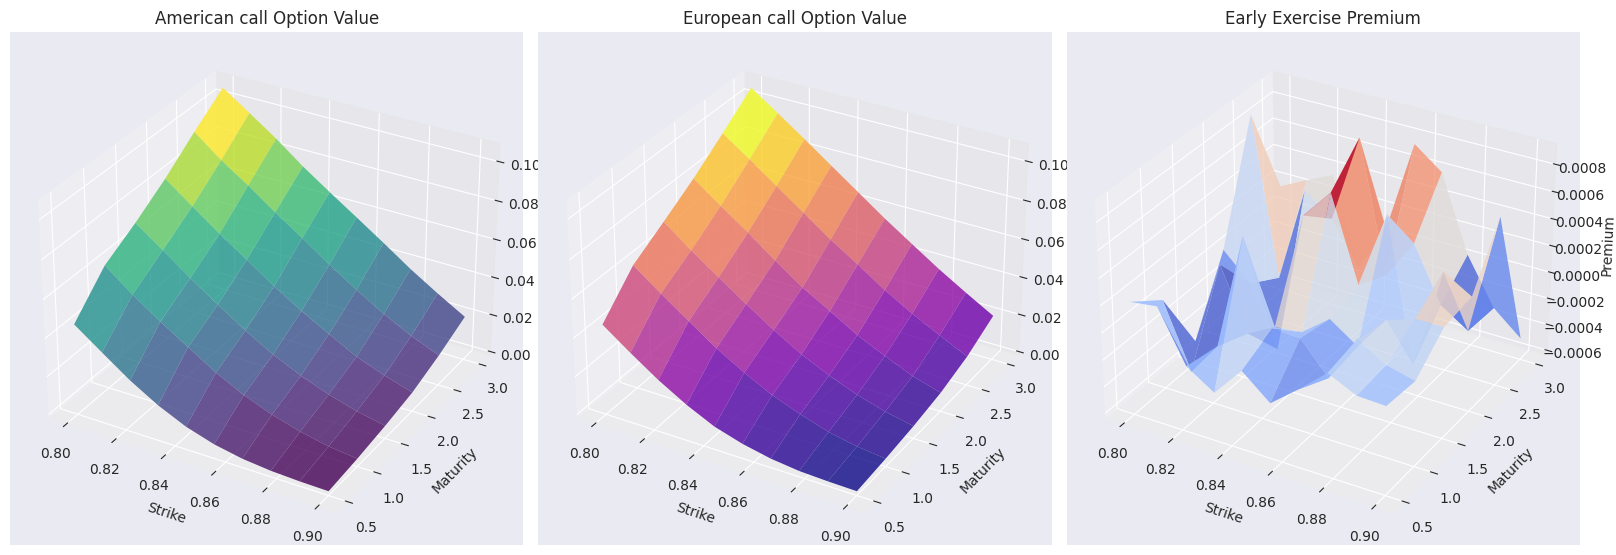


Maximum early exercise premium: $0.0009
Average early exercise premium: $0.0001


In [10]:
# Create a grid of strikes and maturities
strikes_grid = np.linspace(0.80, 0.90, 10)
maturities_grid = np.linspace(0.5, 3.0, 6)
bond_mat = 5.0

# Calculate prices for the grid
american_grid = np.zeros((len(maturities_grid), len(strikes_grid)))
european_grid = np.zeros((len(maturities_grid), len(strikes_grid)))

print("Calculating option prices for surface plot...")
for i, T in enumerate(maturities_grid):
    for j, K in enumerate(strikes_grid):
        # American
        am_res = ls_engine.price_american_option(
            strike=K,
            option_maturity=T,
            bond_maturity=bond_mat,
            option_type='call'
        )
        american_grid[i, j] = am_res['price']
        
        # European
        eu_res = ls_engine.price_european_option(
            strike=K,
            option_maturity=T,
            bond_maturity=bond_mat,
            option_type='call'
        )
        european_grid[i, j] = eu_res['price']

# Create 3D surface plots
fig = plt.figure(figsize=(16, 6))

# American option surface
ax1 = fig.add_subplot(131, projection='3d')
K_mesh, T_mesh = np.meshgrid(strikes_grid, maturities_grid)
surf1 = ax1.plot_surface(K_mesh, T_mesh, american_grid, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Strike')
ax1.set_ylabel('Maturity')
ax1.set_zlabel('Price')
ax1.set_title('American call Option Value')

# European option surface
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(K_mesh, T_mesh, european_grid, cmap='plasma', alpha=0.8)
ax2.set_xlabel('Strike')
ax2.set_ylabel('Maturity')
ax2.set_zlabel('Price')
ax2.set_title('European call Option Value')

# Early exercise premium surface
ax3 = fig.add_subplot(133, projection='3d')
premium_grid = american_grid - european_grid
surf3 = ax3.plot_surface(K_mesh, T_mesh, premium_grid, cmap='coolwarm', alpha=0.8)
ax3.set_xlabel('Strike')
ax3.set_ylabel('Maturity')
ax3.set_zlabel('Premium')
ax3.set_title('Early Exercise Premium')

plt.tight_layout()
plt.show()

print(f"\nMaximum early exercise premium: ${np.max(premium_grid):.4f}")
print(f"Average early exercise premium: ${np.mean(premium_grid):.4f}")

## Summary

This notebook demonstrated the Longstaff-Schwartz method for pricing American options on zero bonds:

1. **Basis Functions**: We use Laguerre polynomials which are well-suited for exponential-like payoffs
2. **Early Exercise Premium**: American options are worth more than European due to the flexibility to exercise early
3. **Exercise Boundary**: The algorithm identifies optimal exercise regions in terms of interest rates and bond prices
4. **Convergence**: The method converges as we increase the number of Monte Carlo paths
5. **Robustness**: Results are stable across different basis function choices

The implementation successfully captures the value of early exercise and provides detailed information about exercise behavior.